# Hadamard Gate Measurement

---

## 1. Problem Statement / Objective
The objective of this experiment is to:
1. **Create a 1-qubit quantum circuit** with 1 classical register using Qiskit.
2. **Apply a Hadamard gate ($H$)** to initialize the qubit into a quantum superposition state.
3. **Measure the qubit** in the computational basis ($Z$-basis) and record the outcome into the classical register.
4. **Execute the circuit for 1024 shots** using the Qiskit **AerSimulator**.
5. **Plot and analyze the measurement histogram** to evaluate the resulting probability distribution.

---

## 2. Theoretical Overview: The Hadamard Gate and Superposition

### The Hadamard Gate ($H$)
The Hadamard gate is a fundamental single-qubit quantum logic gate represented by the unitary matrix:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

### Equal Superposition Creation
When applied to the default ground state $|0\rangle$, the Hadamard gate transforms it into an equal (balanced) superposition of the computational basis states $|0\rangle$ and $|1\rangle$:

$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle$$

Similarly, applying the Hadamard gate to the state $|1\rangle$ yields:

$$H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle$$

In the state $|+\rangle$, the probability amplitudes for both $|0\rangle$ and $|1\rangle$ are equal to $\frac{1}{\sqrt{2}}$.

### 50/50 Probability Distribution
According to the **Born rule**, the probability of measuring a given basis state is the square of the magnitude of its probability amplitude:

$$P(|0\rangle) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 0.5 \quad (50\%)$$

$$P(|1\rangle) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 0.5 \quad (50\%)$$

Consequently, prior to measurement, the qubit exists in a coherent superposition. Upon measurement in the computational basis, the quantum state collapses probabilistically to either $|0\rangle$ or $|1\rangle$. Over a large number of repeated executions (shots), the measurement outcomes should approximately follow an equal **50/50 probability distribution**.

---

## 3. Tools and Libraries Used
- **Qiskit**: IBM's open-source quantum computing software development kit for defining, composing, and visualizing quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: A high-performance quantum simulation framework that emulates quantum hardware execution with realistic statistical sampling over multiple shots.
- **Matplotlib**: A Python plotting and visualization library used for generating bar charts and histograms of the measurement counts.


### Step 1: Import Libraries and Dependencies
Import the necessary modules from Qiskit, Qiskit Aer, and Matplotlib.


In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

### Step 2: Package Installation
Install Qiskit and Qiskit Aer packages into the environment if not already available.


In [2]:
pip install qiskit


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 2.2 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 2.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [qiskit]2m3/4 [qiskit]
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install qiskit_aer

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.6 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


### Step 3: Circuit Construction, Execution, and Measurement
1. Initialize a 1-qubit, 1-classical-bit quantum circuit (`QuantumCircuit(1, 1)`).
2. Apply the Hadamard gate ($H$) to qubit 0 (`qc.h(0)`).
3. Measure qubit 0 into classical bit 0 (`qc.measure(0, 0)`).
4. Visualize the circuit diagram using `qc.draw()`.
5. Execute the circuit on `AerSimulator` for **1024 shots** and extract the counts.
6. Plot the distribution using Qiskit's `plot_histogram`.


In [10]:
qc = QuantumCircuit(1, 1)

qc.h(0)

qc.measure(0, 0)

print(qc.draw())

simulator = AerSimulator()

job = simulator.run(qc, shots=1024)

result = job.result()

counts = result.get_counts()

print("Measurement Counts:", counts)

plot_histogram(counts)
plt.show()

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Measurement Counts: {'1': 519, '0': 505}


### Step 4: Custom Measurement Histogram Visualization
Visualize the measurement counts as a formatted bar chart using Matplotlib with count labels.


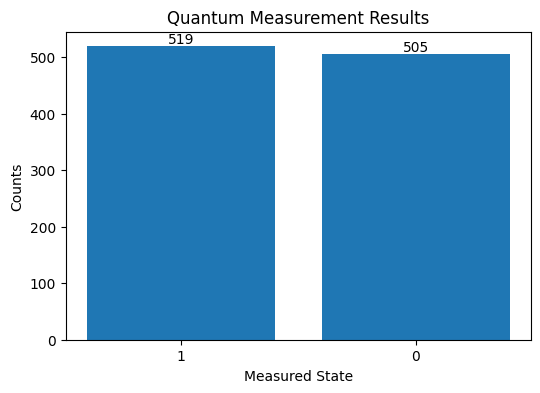

In [11]:
import matplotlib.pyplot as plt

states = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6,4))
plt.bar(states, values)

plt.title("Quantum Measurement Results")
plt.xlabel("Measured State")
plt.ylabel("Counts")

for i, v in enumerate(values):
    plt.text(i, v+5, str(v), ha='center')

plt.show()

---

## Conclusion & Discussion

### Summary of Experimental Results
- **Total Shots Executed**: $1024$
- **Measured Counts**:
  - State $|0\rangle$: $505$ counts
  - State $|1\rangle$: $519$ counts

### Experimental Probability Calculation
The observed probabilities from the $1024$ measurement shots are calculated as:

$$P_{\text{exp}}(|0\rangle) = \frac{\text{Counts}(|0\rangle)}{\text{Total Shots}} = \frac{505}{1024} \approx 0.4932 \quad (49.32\%)$$

$$P_{\text{exp}}(|1\rangle) = \frac{\text{Counts}(|1\rangle)}{\text{Total Shots}} = \frac{519}{1024} \approx 0.5068 \quad (50.68\%)$$

- **Theoretical Target**: $P_{\text{theoretical}}(|0\rangle) = 0.5000$ ($50\%$), $P_{\text{theoretical}}(|1\rangle) = 0.5000$ ($50\%$)
- **Discrepancy / Error**: $|0.4932 - 0.5000| = 0.0068$ ($0.68\%$)

### Key Observations
1. **Demonstration of Superposition**: The measured counts confirm that applying a Hadamard gate to $|0\rangle$ successfully created an equal superposition state $|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$.
2. **Probabilistic Nature of Quantum Measurement**: Measurement in the computational basis collapsed the superposition state into definite classical states ($|0\rangle$ or $|1\rangle$) in a fundamentally probabilistic manner.
3. **Alignment with 50/50 Distribution**: The experimental probabilities of approximately $0.493$ and $0.507$ are very close to the expected theoretical probability of $0.5$ ($50\%$) for each state. The slight variance is entirely consistent with expected statistical sampling fluctuations (shot noise $\approx 1/\sqrt{1024} \approx 3.1\%$) over $1024$ shots.
